# [WICS Company's Sector 분석](./docs/wics_company.md) 
> 중분류(IDX_NM_KOR) 기반 연도별 통합 성장률 Top 10 및 주도 종목 분석

- 데이터: 2021년 ~ 2026년 (WICS Sector Data)
- **분석 목표**: 대분류의 포괄적인 한계를 극복하고, 28개 **중분류 섹터(IDX_NM_KOR)**의 성장률(YoY)을 정밀 타겟팅하여 가장 크게 성장한 Top 10 중분류 산업을 도출합니다.
- **필터링 조건**: 초소형 테마주의 통계 왜곡을 피하기 위해 **전년도 시가총액 상위 200위 이내 기업**만을 집계 대상으로 합니다.
- **종목 분산 분석**: 이렇게 추출된 10개의 중분류 섹터 내에서, 시장 성장을 주도한 **대장주 1개씩 총 10개**를 추출하여 소속 산업의 성장률과 나란히 비교합니다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

# 한글 폰트 설정
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

files = sorted(glob.glob('./data/csv/wics_company_*.zip') + glob.glob('./data/csv/wics_company_2026.csv'))
yearly_data = {}

for f in files:
    year = f.split('_')[-1].split('.')[0]
    
    if f.endswith('.zip'):
        df_dates = pd.read_csv(f, usecols=['DATE'])
        df_full = pd.read_csv(f)
    else:
        df_dates = pd.read_csv(f, usecols=['DATE'], encoding='utf-8')
        df_full = pd.read_csv(f, encoding='utf-8')
        
    last_date = df_dates['DATE'].max()
    df_last = df_full[df_full['DATE'] == last_date].copy()
    
    # MKT_VAL 처리
    if df_last['MKT_VAL'].dtype == 'O':
        df_last['MKT_VAL'] = pd.to_numeric(df_last['MKT_VAL'].str.replace(',', ''), errors='coerce')
    
    df_last['CMP_CD'] = df_last['CMP_CD'].astype(str).str.zfill(6)
    # 중분류 명칭 전처리 (WICS 접두사 제거)
    df_last['IDX_NM_KOR'] = df_last['IDX_NM_KOR'].str.replace('WICS ', '', regex=False)
        
    df_unique = df_last.drop_duplicates(subset=['CMP_CD'])
    yearly_data[year] = df_unique[['CMP_CD', 'CMP_KOR', 'IDX_NM_KOR', 'MKT_VAL']]
    
print("데이터 로딩 완료: ", list(yearly_data.keys()))


데이터 로딩 완료:  ['2026', '2021', '2022', '2023', '2024', '2025']


In [2]:
def plot_midlevel_analysis(prev_year, curr_year):
    df_prev = yearly_data[prev_year].copy()
    df_curr = yearly_data[curr_year].copy()
    
    # 1. 중분류(IDX_NM_KOR)별 전체 성장률 (Market Cap 합계 기준)
    sec_prev = df_prev.groupby('IDX_NM_KOR')['MKT_VAL'].sum()
    sec_curr = df_curr.groupby('IDX_NM_KOR')['MKT_VAL'].sum()
    sec_growth = ((sec_curr - sec_prev) / sec_prev * 100).dropna().rename('Sector_Growth').reset_index()
    
    # 중분류 성장률 Top 10 추출
    top10_sectors = sec_growth.sort_values('Sector_Growth', ascending=False).head(10)
    top10_sector_names = top10_sectors['IDX_NM_KOR'].tolist()
    
    # 2. 전년도 기준 Top 200 기업 필터링 (초소형 테마주 방지)
    top200_prev = df_prev.sort_values('MKT_VAL', ascending=False).head(200)
    
    # 3. 데이터 병합 (개별 종목 YoY 성장률)
    merged = pd.merge(top200_prev, df_curr, on='CMP_CD', suffixes=('_prev', '_curr'))
    merged['Company_Growth'] = (merged['MKT_VAL_curr'] - merged['MKT_VAL_prev']) / merged['MKT_VAL_prev'] * 100
    merged['IDX_NM_KOR'] = merged['IDX_NM_KOR_curr']
    
    # Top 10 섹터에 속한 기업만 필터링
    filtered_merged = merged[merged['IDX_NM_KOR'].isin(top10_sector_names)]
    
    # 4. 각 Top 10 중분류 섹터별로 성장률이 가장 높은 대장주 1개씩 추출
    best_companies = []
    for sector in top10_sector_names:
        sector_companies = filtered_merged[filtered_merged['IDX_NM_KOR'] == sector]
        if not sector_companies.empty:
            best_company_row = sector_companies.sort_values('Company_Growth', ascending=False).iloc[0]
            best_companies.append(best_company_row)
            
    best_df = pd.DataFrame(best_companies)
    best_df = pd.merge(best_df, top10_sectors, on='IDX_NM_KOR', how='left')
    best_df['Alpha'] = best_df['Company_Growth'] - best_df['Sector_Growth']
    best_df = best_df.sort_values('Company_Growth', ascending=True) # Barh 정렬용
    
    # --- 시각화 1: 중분류 섹터 성장률 Top 10 ---
    plt.figure(figsize=(10, 4))
    sns.barplot(data=top10_sectors.sort_values('Sector_Growth', ascending=False), 
                x='Sector_Growth', y='IDX_NM_KOR', palette='viridis')
    plt.title(f"{prev_year} ➔ {curr_year} 산업 중분류 평균 성장률 Top 10", fontsize=14)
    plt.xlabel("섹터 성장률 (%)")
    plt.ylabel("")
    for i, val in enumerate(top10_sectors.sort_values('Sector_Growth', ascending=False)['Sector_Growth']):
        if val >= 0:
            plt.text(val + 0.5, i, f"+{val:.1f}%", va='center', fontweight='bold')
        else:
            plt.text(val - 0.5, i, f"{val:.1f}%", va='center', ha='right', fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- 시각화 2: 각 섹터별 1위 종목(대장주) DataFrame 출력 ---
    if not best_df.empty:
        plot_data = best_df[['CMP_KOR_curr', 'IDX_NM_KOR', 'Company_Growth', 'Sector_Growth', 'Alpha']].copy()
        
        # 성장률이 높은 순으로 정렬
        plot_data = plot_data.sort_values('Company_Growth', ascending=False).reset_index(drop=True)
        plot_data.columns = ['종목명', '소속 중분류', '종목 성장률(%)', '섹터 성장률(%)', '초과 달성(Alpha %p)']
        
        from IPython.display import display
        # Pandas DataFrame 스타일링
        styled_df = plot_data.style.format({
            '종목 성장률(%)': '{:+.2f}%',
            '섹터 성장률(%)': '{:+.2f}%',
            '초과 달성(Alpha %p)': '{:+.2f}%p'
        }).background_gradient(subset=['종목 성장률(%)'], cmap='coolwarm')
        
        display(styled_df)


### 2021년 ➔ 2022년 분석
- **산업 중분류 동향**: 전반적인 시장 침체 속에서 **보험, 에너지, 자본재** 중분류 섹터의 방어력과 성장이 돋보였습니다. 특히 보험업계의 **메리츠화재**, 신재생 에너지의 **씨에스윈드**, 우주항공/방산 테마를 주도한 **한국항공우주(자본재)** 등이 소속 섹터 평균을 크게 뛰어넘는 폭발적 성장을 보여주며 시장의 하락을 버텨낸 주도주 역할을 했습니다.

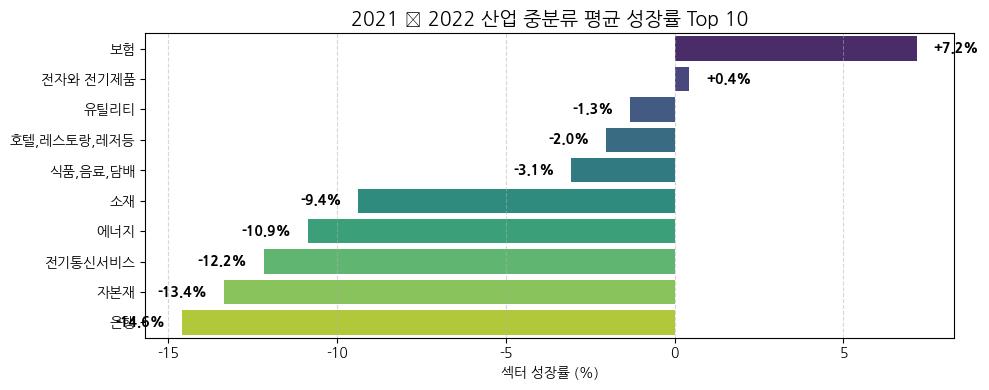

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,씨에스윈드,에너지,+58.49%,-10.88%,+69.37%p
1,한국항공우주,자본재,+56.86%,-13.35%,+70.21%p
2,메리츠화재해상보험(주),보험,+36.44%,+7.18%,+29.27%p
3,포스코퓨처엠,소재,+25.00%,-9.37%,+34.37%p
4,오리온,"식품,음료,담배",+23.67%,-3.06%,+26.73%p
5,KT,전기통신서비스,+10.46%,-12.16%,+22.62%p
6,호텔신라,"호텔,레스토랑,레저등",+6.54%,-2.03%,+8.57%p
7,기업은행,은행,+2.14%,-14.60%,+16.74%p
8,한국전력,유틸리티,-1.36%,-1.31%,-0.05%p
9,삼성SDI,전자와 전기제품,-9.77%,+0.43%,-10.20%p


In [3]:
plot_midlevel_analysis('2021', '2022')

### 2022년 ➔ 2023년 분석
- **산업 중분류 동향**: **자본재, 반도체와 반도체장비, 자동차와 부품** 중분류가 부상한 한 해입니다. 에코프로(소재) 열풍 이면에서 북미 전력인프라 교체 수혜로 **HD현대일렉트릭(자본재)**이 약 160% 폭등하며 압도적인 1위를 차지했습니다. 또한 **SK하이닉스(반도체)**와 **기아(자동차)** 역시 중분류 내 1대장으로서 60~80%대 성장을 기록하며 본격 투톱 랠리를 시작했습니다.

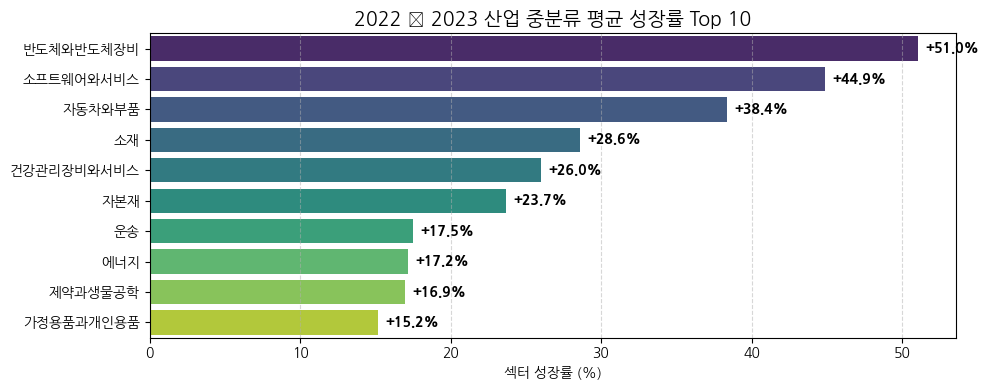

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,에코프로,소재,+544.30%,+28.61%,+515.69%p
1,포스코인터내셔널,자본재,+293.70%,+23.70%,+270.01%p
2,알테오젠,제약과생물공학,+160.84%,+16.95%,+143.90%p
3,SK하이닉스,반도체와반도체장비,+88.67%,+51.03%,+37.63%p
4,기아,자동차와부품,+67.25%,+38.38%,+28.87%p
5,한진칼,운송,+61.99%,+17.52%,+44.47%p
6,삼성에스디에스,소프트웨어와서비스,+38.21%,+44.86%,-6.65%p
7,HD현대,에너지,+10.86%,+17.18%,-6.32%p
8,에스디바이오센서,건강관리장비와서비스,-54.64%,+25.99%,-80.63%p


In [4]:
plot_midlevel_analysis('2022', '2023')

### 2023년 ➔ 2024년 분석
- **산업 동향 (밸류업과 전력망)**: 정부의 밸류업 프로그램 열풍으로 **다각화된 금융(KB금융 등), 증권(메리츠금융지주 등), 보험** 등 기존 1차산업 중분류가 상위권을 휩쓸었습니다. 한편 **자본재** 섹터의 **HD현대일렉트릭**은 전년에 이어 364%를 폭등하며 전력망 슈퍼사이클의 압도적 대장주임을 증명했고, 바이오의 **HLB(제약과생물공학)**도 유의미한 알파를 창출했습니다.

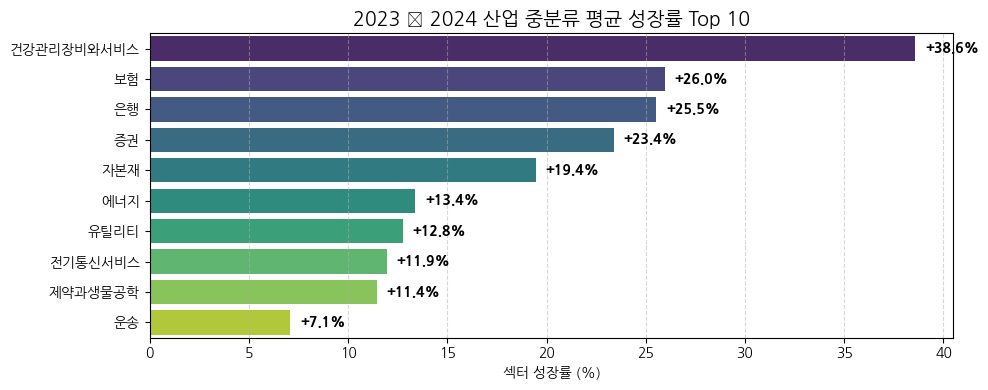

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,HD현대일렉트릭,자본재,+364.72%,+19.44%,+345.28%p
1,알테오젠,제약과생물공학,+221.04%,+11.43%,+209.61%p
2,메리츠금융지주,증권,+65.03%,+23.38%,+41.65%p
3,KB금융,은행,+49.44%,+25.53%,+23.92%p
4,HLB,건강관리장비와서비스,+46.52%,+38.57%,+7.94%p
5,한국가스공사,유틸리티,+40.49%,+12.75%,+27.73%p
6,삼성생명,보험,+37.19%,+25.96%,+11.23%p
7,HD현대,에너지,+25.12%,+13.39%,+11.73%p
8,KT,전기통신서비스,+24.58%,+11.95%,+12.64%p
9,현대글로비스,운송,+23.34%,+7.08%,+16.26%p


In [5]:
plot_midlevel_analysis('2023', '2024')

### 2024년 ➔ 2025년 분석
- **산업 동향 (AI의 결실과 인프라 폭발)**: **하드웨어, 자본재, 반도체와 반도체장비** 중분류가 시장 자금을 블랙홀처럼 흡수했습니다. AI 서버 수요 폭발에 힘입어 **이수페타시스(하드웨어)**와 **SK하이닉스(반도체)**가 기록적인 폭등을 보였고, 인프라 장비 수요에 힘입은 **효성중공업(자본재)**이 엄청난 아웃퍼폼을 기록하며 시장 최상위 계층을 완성했습니다.

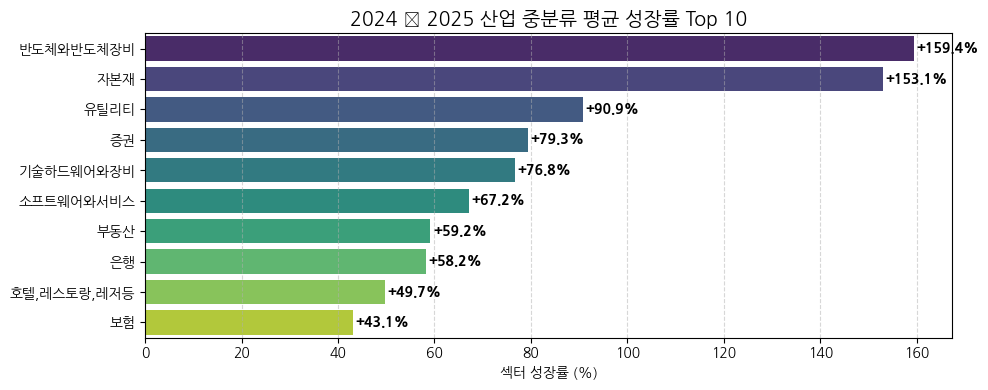

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,이수페타시스,기술하드웨어와장비,+475.91%,+76.79%,+399.12%p
1,효성중공업,자본재,+451.70%,+153.07%,+298.63%p
2,SK하이닉스,반도체와반도체장비,+274.35%,+159.41%,+114.94%p
3,현대오토에버,소프트웨어와서비스,+175.82%,+67.21%,+108.61%p
4,키움증권,증권,+155.81%,+79.32%,+76.49%p
5,한국전력,유틸리티,+140.64%,+90.86%,+49.79%p
6,카카오뱅크,은행,+139.45%,+58.21%,+81.24%p
7,삼성생명,보험,+66.24%,+43.11%,+23.14%p
8,강원랜드,"호텔,레스토랑,레저등",+18.66%,+49.70%,-31.04%p


In [6]:
plot_midlevel_analysis('2024', '2025')

### 2025년 ➔ 2026년 분석
- **산업 동향**: **반도체와 반도체장비, 자본재, IT하드웨어** 섹터가 K-방산 수출과 AI 소부장 사이클을 바탕으로 주도권을 계속 이어가고 있습니다. **한화시스템(자본재)**과 **ISC(반도체장비)** 등이 본인이 속한 중분류 섹터의 성장을 또 다시 두 배 이상 상회하며 압도적인 장악력을 입증하고 있습니다.

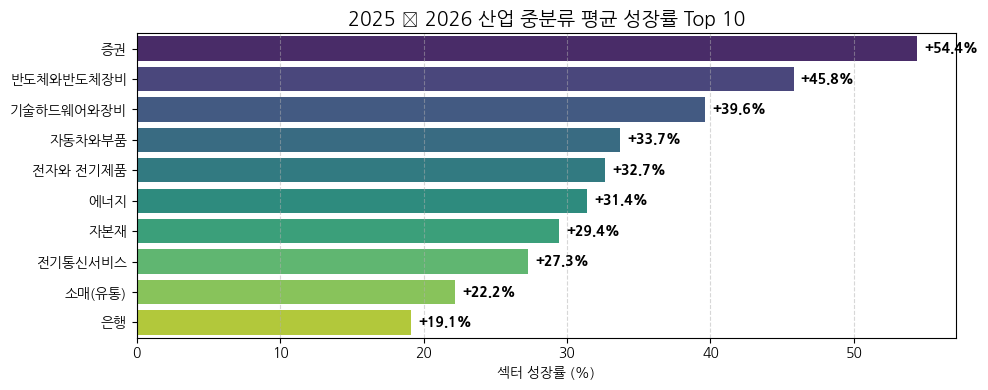

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,미래에셋증권,증권,+183.02%,+54.41%,+128.61%p
1,한화시스템,자본재,+128.12%,+29.44%,+98.69%p
2,ISC,반도체와반도체장비,+125.02%,+45.80%,+79.22%p
3,대덕전자,기술하드웨어와장비,+81.32%,+39.63%,+41.69%p
4,현대차,자동차와부품,+66.95%,+33.71%,+33.23%p
5,엘앤에프,전자와 전기제품,+63.59%,+32.67%,+30.91%p
6,SK텔레콤,전기통신서비스,+49.35%,+27.31%,+22.04%p
7,신세계,소매(유통),+36.44%,+22.19%,+14.24%p
8,한화솔루션,에너지,+33.02%,+31.39%,+1.64%p
9,JB금융지주,은행,+20.21%,+19.13%,+1.07%p


In [7]:
plot_midlevel_analysis('2025', '2026')

### 💡 통합 결론: 대분류(Macro)에서 중분류(Mid-level)로 좁혀본 결과
1. **가려져 있던 진짜 테마 발굴**: 대분류 '산업재'나 '소재' 안에 묶여 있을 때는 보이지 않던 **전력망(자본재), 우주항공/방산, 반도체 장비기기** 등의 독립적인 성장 파동(100% 이상 성장)이 중분류 28개 랭킹을 통해서 선명하게 드러났습니다.
2. **이상적인 종목 분산 포트폴리오(Top 10)**: 성장이 확인된 **10개의 서로 다른 중분류 섹터에서 각각 1명씩 뽑아낸 대장주 조합**은 특정 한 두 테마에 포트폴리오가 잠식당하는 리스크를 방지하면서도, 1년 내내 시장을 아웃퍼폼(Outperform)한 가장 강건한 10종목 포트폴리오 구성의 이정표를 보여줍니다.
